In [1]:
import ast
import ipynbname
import pandas as pd
import numpy as np
from Functions.AutoCloud import *
from Functions.Utils import *
from Functions.Graphs import *
from Functions.TedaGraphs import *
from Functions.Utils_OPT import *
from Functions.TedaOptimize_GD import *

FileName = ipynbname.name()
out_path = f'Optimization\\{FileName[:-4]}\\multi\\Optimization.csv'
RS = pd.read_excel(r'Dataset\RS.xlsx')
HI = pd.read_excel(r'Dataset\HI.xlsx')
sig = HI['PC1'].values

In [2]:
df = Optimize(FileName=FileName[:-4],OptDim=1,OptSampler='none',OptPrune=True,
                         n_study=1,timeout=600,n_trials=2e3,patience=1e2,
                         mS=[2.0,4.5],nRS=[1,70],mdS=[1,1],actS=[0,1])

BEST TRIAL
Trial #945 | Valor: 0.2620 | Params: {'m': 2.75, 'nI': 10, 'n_layers': 2, 'nR_layer_0': 64, 'nR_layer_1': 22, 'nO': 17, 'N1': 1, 'N2': 9, 'N3': 6, 'τ': 1, 'mode': 1, 'act': 0, 'mO': 9}

LAST 3 TRIALS
Trial #1997 [PRUNED]
Trial #1998 [PRUNED]
Trial #1999 [PRUNED]
--------------------------------------------------------------------------------
STOPPING STATUS: 30/100.0 ITERATIONS WITHOUT IMPROVEMENT.
--------------------------------------------------------------------------------


UnboundLocalError: local variable 'df_stdy' referenced before assignment

In [ ]:
for i in range(1,6):
    df = Optimize(FileName=FileName[:-4],OptDim=1,OptSampler='tpe',OptPrune=True,
                         n_study=1,timeout=600,n_trials=2e3,patience=1e2,
                         mS=[2.0,4.5],nLS=[i,i],nRS=[1,70],mdS=[1,1],actS=[0,1])

In [12]:
#df = df[(df.iloc[:,0] <= 0.07)]
params_list = df.values[:,-11:]
df

,MAPE_RUL*MAPE_HI,m,nI,nR,nO,mO,N1,N2,N3,TAU,past/ahead,activation
309,3.780042,4.00,13,[36],13,7,5,4,2,17.644620,1,0
109,3.574782,3.50,12,[38],11,0,7,9,6,18.038102,0,0
110,3.570847,2.50,29,"[52, 22, 54, 20, 58]",2,0,2,2,9,15.081297,0,1
139,3.553961,1.75,40,"[2, 60, 2, 49]",1,0,9,4,4,7.835866,0,0
104,3.134409,2.50,28,"[43, 7, 18, 45, 2]",8,0,2,8,1,11.249661,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
27,0.067086,3.50,20,[47],20,5,1,9,8,1.220245,1,0
192,0.066589,3.50,20,"[50, 6, 65]",17,5,1,3,3,12.283054,1,0
28,0.065454,3.50,17,[28],13,8,1,5,9,14.292155,1,0
29,0.061630,3.00,12,"[19, 29]",11,4,1,3,4,1.049707,1,0


In [4]:
tedas = []
for i,params in enumerate(params_list[-1:]):
    m,nI,nR,nO,mO,N1,N2,N3,τ,mode,act = params
    X, Y, Z = PrepareData(RS, HI, nI, nO, mO, 1, mode)
    if isinstance(nR, str): nR = ast.literal_eval(nR)

    teda=AutoCloud(m=m,nI=len(Y[0]),nR=nR,nO=nO+mO,ηS=[N1,N2,N3],mode=mode,act=act,
                tau=τ,rho=0.001,eol=0.3,ref=len(sig)-nI+1,wtaG=True,wtaP=True) 
    for j,_ in enumerate(X[:]):
        teda.run(X[j])
        teda.RUL_Prediction(Y[j],mode='interval',lim=len(sig)-nI+1,show=False)
        teda.Adapt(Y[j],Z[j])

    teda.c = np.append(teda.c,teda.gm)  
    tedas.append(teda)
    #PlotSeriesPLY(ySeries=[teda.wape_HI_hist,teda.wape_RUL_hist])

In [8]:
for cloud in teda.c:
    print(cloud.ID, cloud.rnn.wR[0][1][:5])

1 [ 0.11984414 -0.07904305 -0.02127377 -0.13827311 -0.11758025]
2 [ 0.11983974 -0.07903787 -0.02127143 -0.13827439 -0.11758093]
GM [ 0.11983224 -0.07903042 -0.02126986 -0.13828132 -0.11757959]


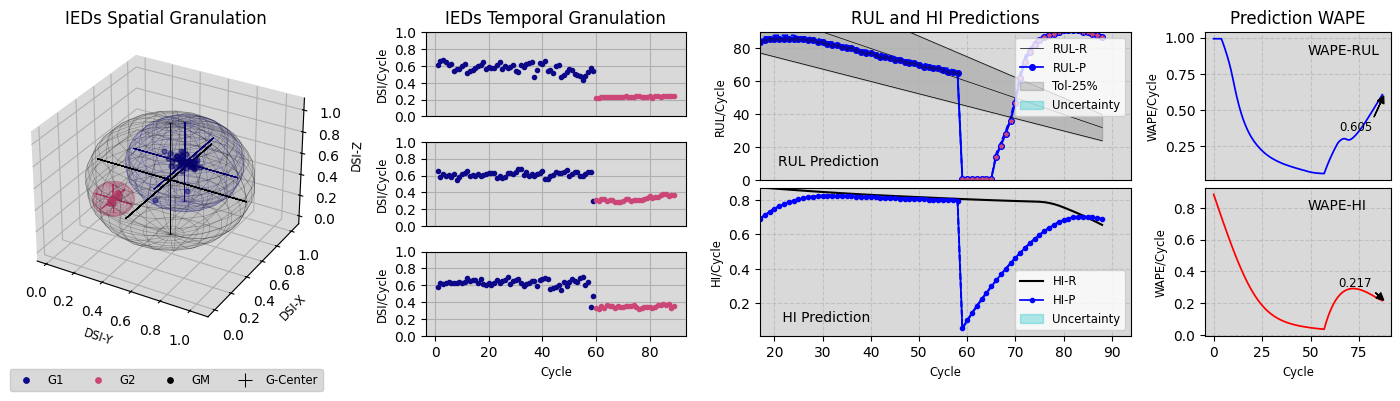

In [5]:
PlotDSI_3D_PLT(tedas[-1])